In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import os
import glob
import calendar

In [6]:
# Load CHIRPS dataset
chirps_ds = xr.open_dataset("data/CHIRPS/chirps-v2.0.monthly.nc")

In [79]:
sst = xr.open_dataset('data/SST/sst.mnmean.nc')
sst = sst.assign_coords(lon=(((sst.lon + 180) % 360) - 180)).sortby(['lon'])
sst_df = sst.to_dataframe().reset_index()
sst_df = sst_df.query('time_bnds > 0 and nbnds == 0')
sst_df['month'] = sst_df['time'].dt.month
sst_df['year'] = sst_df['time'].dt.year
sst_df = sst_df.query('year >= 1993 and year <= 2024').reset_index().drop(['index'], axis=1)

In [7]:
# Define all regions with lat/lon bounds
regions = {
    "south_sudan": {
        "lat_range": [3.5, 12.5],
        "lon_range": [25, 35]
    },
    "eastern_east_africa": {
        "lat_range": [-3.5, 8.5],
        "lon_range": [38, 50]
    },
    "eastern_ukraine": {
        "lat_range": [45, 51],
        "lon_range": [31, 40]
    },
    "southern_africa": {
        "lat_range": [-23, -15],
        "lon_range": [25, 34]
    },
    "west_africa": {
        "lat_range": [10, 13.5],
        "lon_range": [-10, 0]
    },
    "sri_lanka": {
        "lat_range": [5.5, 10],
        "lon_range": [79.5, 82]
    },
    "lake_victoria": {
        "lat_range": [-4, 1.5],
        "lon_range": [29, 36]
    }
}

seasons_by_region = {
    "eastern_east_africa": ["MAM", "OND"],
    "lake_victoria": ["DJF", "MAM", "SON"],
    "west_africa": ["JAS"],
    "southern_africa": ["DJF", "FMA"],
    "south_sudan": ["MJJ", "JAS", "ASO"],
    "eastern_ukraine": ["DJF", "AMJ", "JA"],
    "sri_lanka": ["OND"]
}

In [118]:
def get_season_months(season):
    """Returns list of months and whether the season crosses calendar years."""
    season_months = {
        'DJF': ([12, 1, 2], True),
        'MAM': ([3, 4, 5], False),
        'OND': ([10, 11, 12], False),
        'SON': ([9, 10, 11], False),
        'JAS': ([7, 8, 9], False),
        'FMA': ([2, 3, 4], False),
        'MJJ': ([5, 6, 7], False),
        'ASO': ([8, 9, 10], False),
        'AMJ': ([4, 5, 6], False),
        'JA': ([7, 8], False)
    }
    return season_months[season]

def get_seasonal_precip(chirps, season, lat_range, lon_range):
    """Aggregates CHIRPS to seasonal precip over a region."""
    months, crosses_year = get_season_months(season)
    region = chirps.sel(latitude=slice(lat_range[0], lat_range[1]), longitude=slice(lon_range[0], lon_range[1]))
    df = region.precip.to_dataframe().dropna().reset_index()
    df['year'] = df['time'].dt.year
    df['month'] = df['time'].dt.month
    df = df.query('year >= 1993 and year <= 2024')

    # Handle cross-year seasons (e.g. DJF)
    if crosses_year:
        df['season_year'] = np.where(df['month'] == months[0], df['year'], df['year'] - 1)
    else:
        df['season_year'] = df['year']

    seasonal = df.query('month in @months').groupby(['season_year'])['precip'].mean().reset_index()

    return seasonal

def get_tercile_years(seasonal_series):
    """Returns years in Above Normal (top tercile) and Below Normal (bottom tercile)."""
    lower = seasonal_series['precip'].quantile(1/3)
    upper = seasonal_series['precip'].quantile(2/3)

    an_years = seasonal_series.query('precip >= @upper')['season_year'].tolist()
    bn_years = seasonal_series.query('precip <= @lower')['season_year'].tolist()

    return {'an' : an_years, 'bn' : bn_years}

In [39]:
seasonal_avg_dict = {}

for region in regions.keys():
    for season in seasons_by_region[region]:
        seasonal_avg_dict[(region, season)] = get_seasonal_precip(chirps_ds, season, regions[region]['lat_range'], regions[region]['lon_range'])

In [67]:
tercile_years_dict = {}
for region, season in seasonal_avg_dict.keys():
    tercile_years_dict[(region, season)] = get_tercile_years(seasonal_avg_dict[(region, season)])

In [74]:
tercile_years_dict

{('south_sudan',
  'MJJ'): {'an': [1994,
   1996,
   2001,
   2007,
   2011,
   2012,
   2013,
   2016,
   2017,
   2018,
   2019], 'bn': [1997,
   1999,
   2002,
   2004,
   2005,
   2006,
   2008,
   2009,
   2015,
   2022,
   2023]},
 ('south_sudan',
  'JAS'): {'an': [1995,
   1996,
   1998,
   1999,
   2000,
   2001,
   2003,
   2007,
   2011,
   2012,
   2017], 'bn': [1993,
   1997,
   2002,
   2004,
   2005,
   2008,
   2009,
   2015,
   2016,
   2021,
   2023]},
 ('south_sudan',
  'ASO'): {'an': [1995,
   1996,
   1998,
   1999,
   2001,
   2003,
   2010,
   2011,
   2012,
   2018,
   2019], 'bn': [1993,
   2002,
   2004,
   2005,
   2008,
   2009,
   2016,
   2021,
   2022,
   2023,
   2024]},
 ('eastern_east_africa',
  'MAM'): {'an': [1995,
   1997,
   1998,
   2003,
   2006,
   2010,
   2013,
   2018,
   2020,
   2023,
   2024], 'bn': [1999,
   2000,
   2001,
   2004,
   2008,
   2009,
   2011,
   2017,
   2019,
   2021,
   2022]},
 ('eastern_east_africa',
  'OND'): {'an': [1

In [106]:
ltm_sst = sst_df.dropna().groupby(['lat', 'lon', 'month']).mean('sst').reset_index()
ltm_sst['std'] = sst_df.dropna().groupby(['lat', 'lon', 'month']).std().reset_index()['sst']
ltm_sst_clean = ltm_sst.drop(['time_bnds', 'nbnds', 'year'], axis=1)
ltm_sst_clean = ltm_sst_clean.rename(columns={'sst':'ltm_sst'})

sst_anomaly = sst_df.drop(['time_bnds', 'nbnds'], axis=1).merge(ltm_sst_clean, on=['lat', 'lon', 'month'], how='left')
sst_anomaly['sst_anomaly'] = sst_anomaly['sst'] - sst_anomaly['ltm_sst']
sst_anomaly['normalized_sst_anomaly'] = sst_anomaly['sst_anomaly'] / sst_anomaly['std']

In [114]:
sst_anomaly.dropna().groupby(['lat', 'lon', 'month'])['normalized_sst_anomaly'].mean().reset_index()

,lat,lon,month,normalized_sst_anomaly
0,-76.0,-180.0,1,-2.793968e-09
1,-76.0,-180.0,2,-8.847564e-08
2,-76.0,-180.0,3,1.471490e-07
3,-76.0,-180.0,11,4.647300e-07
4,-76.0,-180.0,12,3.515743e-08
...,...,...,...,...
117256,88.0,174.0,10,-4.467089e-06
117257,88.0,176.0,9,-3.736932e-06
117258,88.0,176.0,10,-2.408400e-06
117259,88.0,178.0,9,-5.923212e-07


In [119]:
# Function to extract and standardize SST for a season & valid year list
def get_standardized_sst_anomaly(sst_df):
    ltm_sst = sst_df.dropna().groupby(['lat', 'lon', 'month']).mean('sst').reset_index()
    ltm_sst['std'] = sst_df.dropna().groupby(['lat', 'lon', 'month']).std().reset_index()['sst']
    ltm_sst_clean = ltm_sst.drop(['time_bnds', 'nbnds', 'year'], axis=1)
    ltm_sst_clean = ltm_sst_clean.rename(columns={'sst':'ltm_sst'})

    sst_anomaly = sst_df.drop(['time_bnds', 'nbnds'], axis=1).merge(ltm_sst_clean, on=['lat', 'lon', 'month'], how='left')
    sst_anomaly['sst_anomaly'] = sst_anomaly['sst'] - sst_anomaly['ltm_sst']
    sst_anomaly['normalized_sst_anomaly'] = sst_anomaly['sst_anomaly'] / sst_anomaly['std']

    return sst_anomaly

def seasonal_avg_sst_anomaly(anomaly_df, tercile_years):

    return None

In [125]:
region = 'south_sudan'
season = 'MJJ'

sst = get_standardized_sst_anomaly(sst_df.query('month in @months'))
sst.where(sst['year'] in tercile_years_dict[(region, season)]['an'])

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [124]:
1994 in tercile_years_dict[(region, season)]['an']

True

In [105]:
# Dictionary to store SST anomalies
global_sst_anomalies = {}

for region in regions.keys():
    for season in seasons_by_region[region]:
        months, crosses_year = get_season_months(season)
        sst = get_standardized_sst_anomaly(sst_df.query('month in @months'))
        an_sst = sst.where(sst['year'] in tercile_years_dict[(region, season)]['an'])
        bn_sst = sst.where(sst['year'] in tercile_years_dict[(region, season)]['bn'])
        sst = sst.groupby(['lat', 'lon', 'month']).mean('normalized_sst_anomaly').reset_index()



[5, 6, 7]
[7, 8, 9]
[8, 9, 10]
[3, 4, 5]
[10, 11, 12]
[12, 1, 2]
[4, 5, 6]
[7, 8]
[12, 1, 2]
[2, 3, 4]
[7, 8, 9]
[10, 11, 12]
[12, 1, 2]
[3, 4, 5]
[9, 10, 11]


Displaying: south_sudan_MJJ_BN


/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


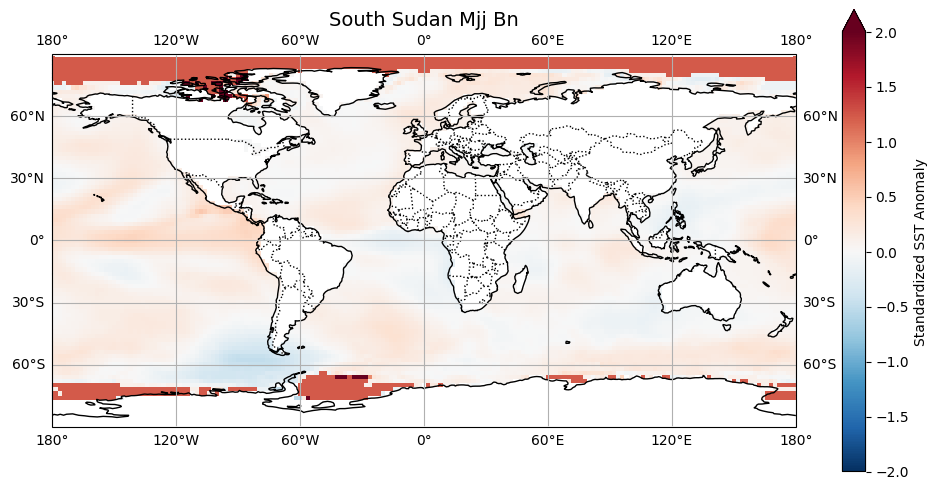

Displaying: south_sudan_MJJ_AN


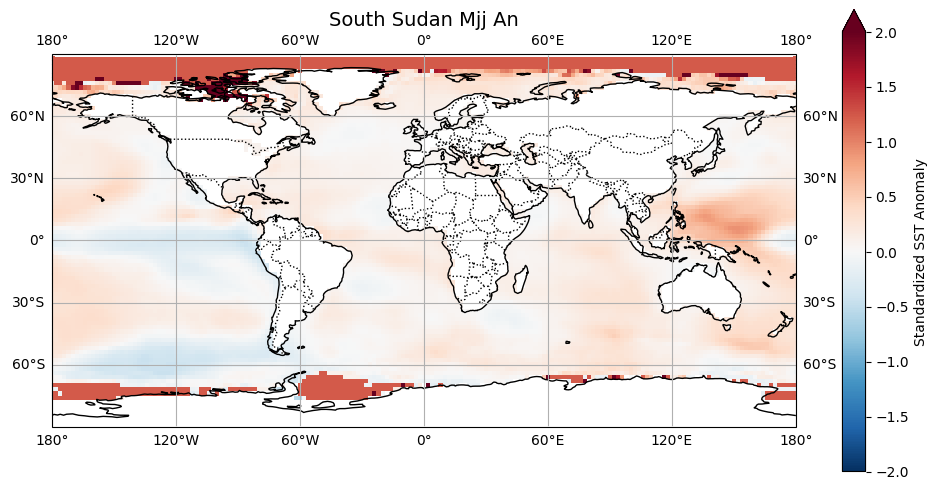

Displaying: south_sudan_JAS_BN


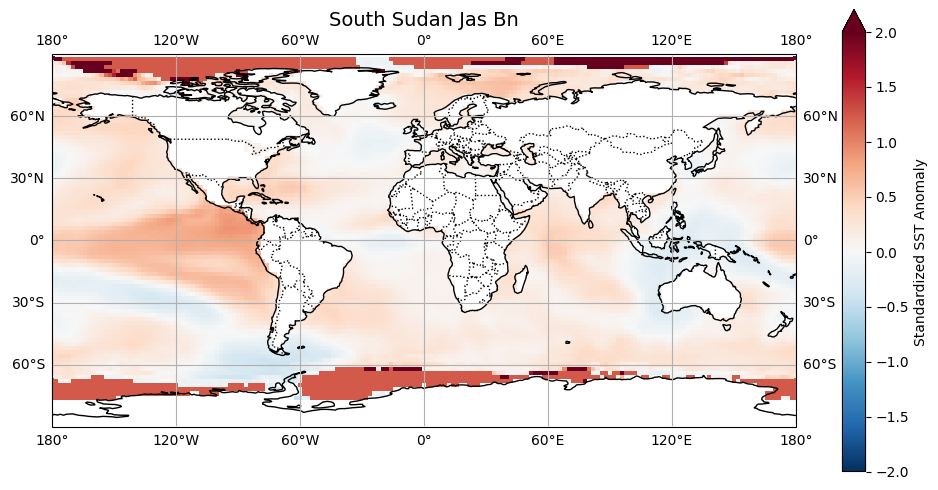

Displaying: south_sudan_JAS_AN


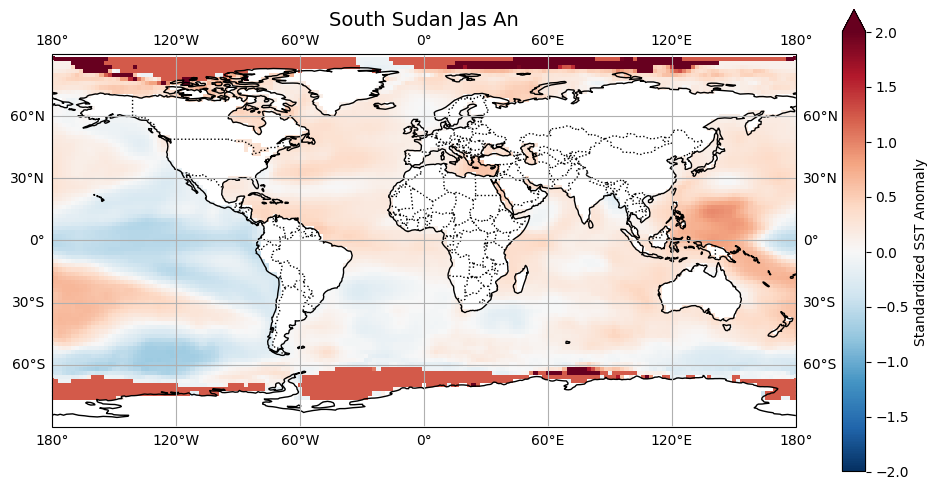

Displaying: south_sudan_ASO_BN


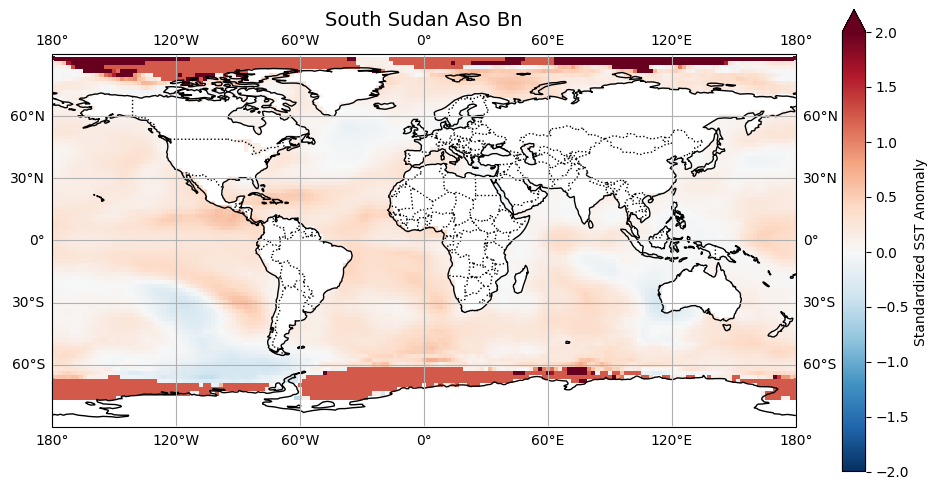

Displaying: south_sudan_ASO_AN


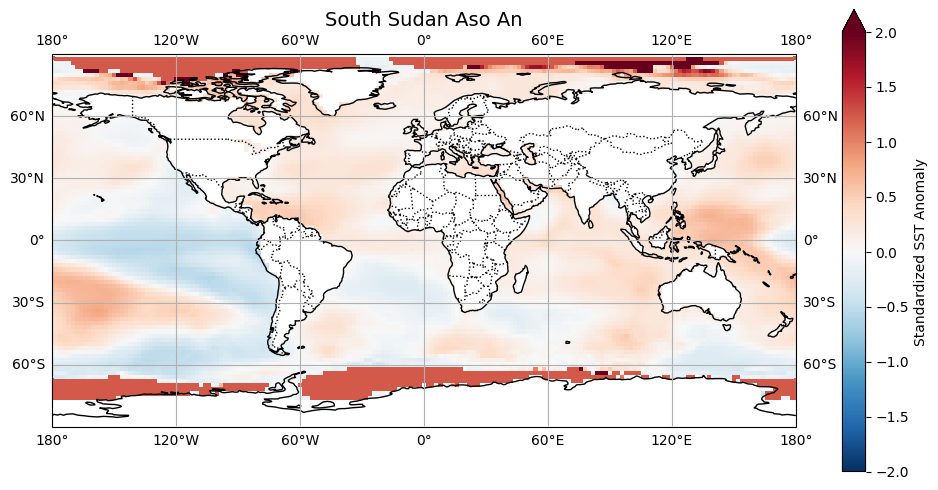

Displaying: eastern_east_africa_MAM_BN


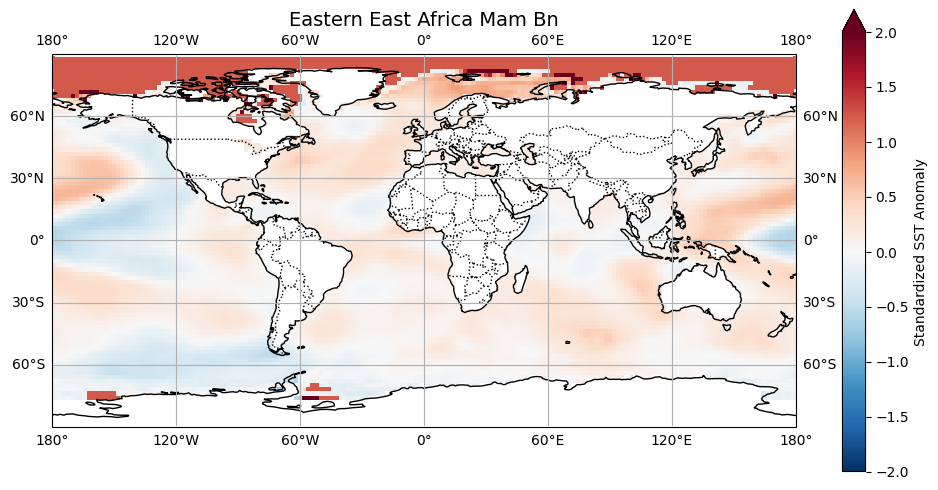

Displaying: eastern_east_africa_MAM_AN


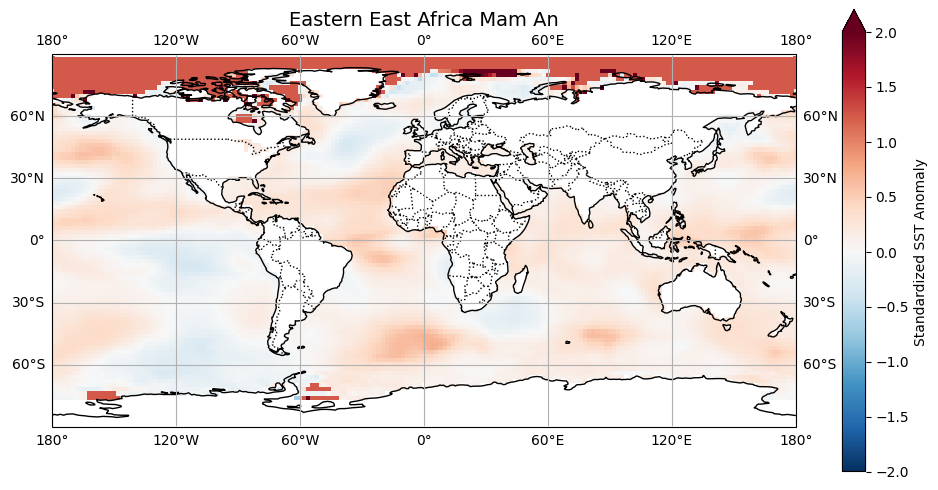

Displaying: eastern_east_africa_OND_BN


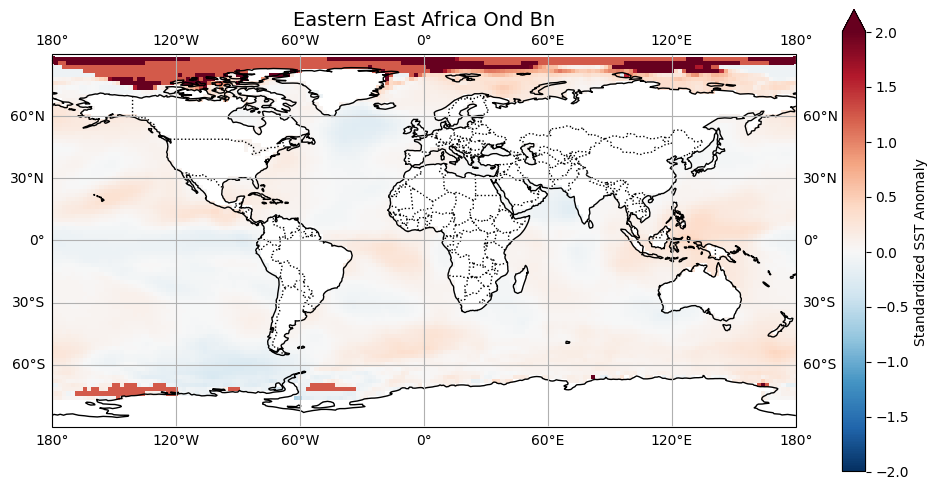

Displaying: eastern_east_africa_OND_AN


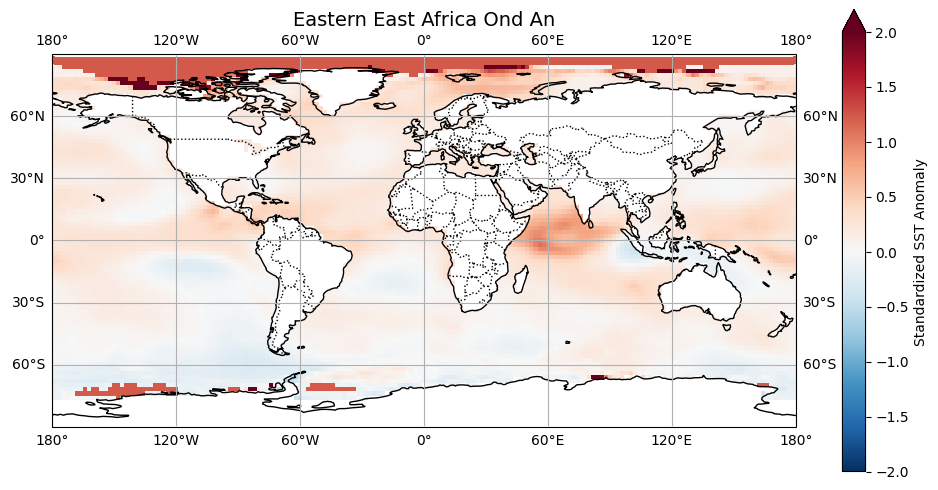

Displaying: eastern_ukraine_DJF_BN


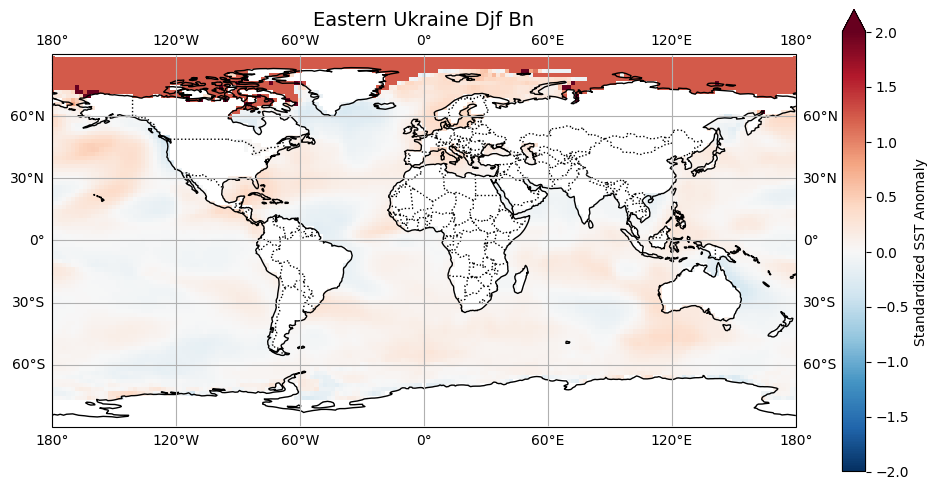

Displaying: eastern_ukraine_DJF_AN


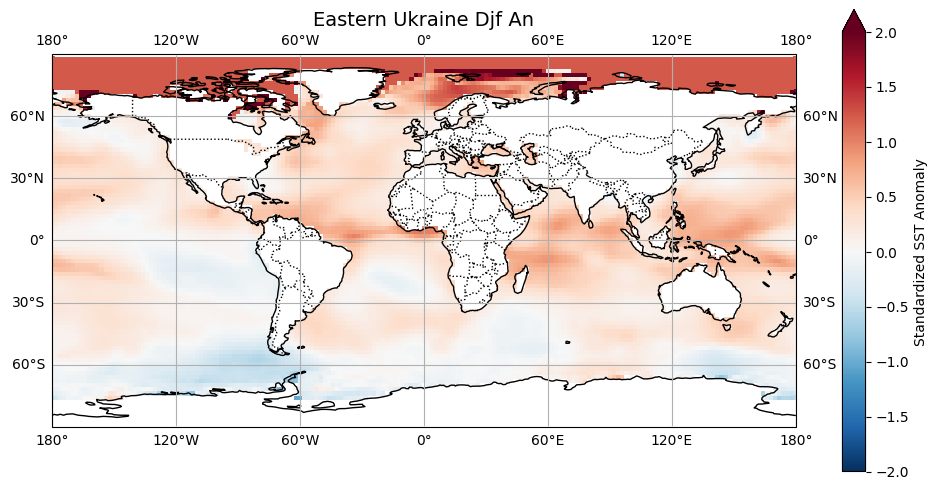

Displaying: eastern_ukraine_AMJ_BN


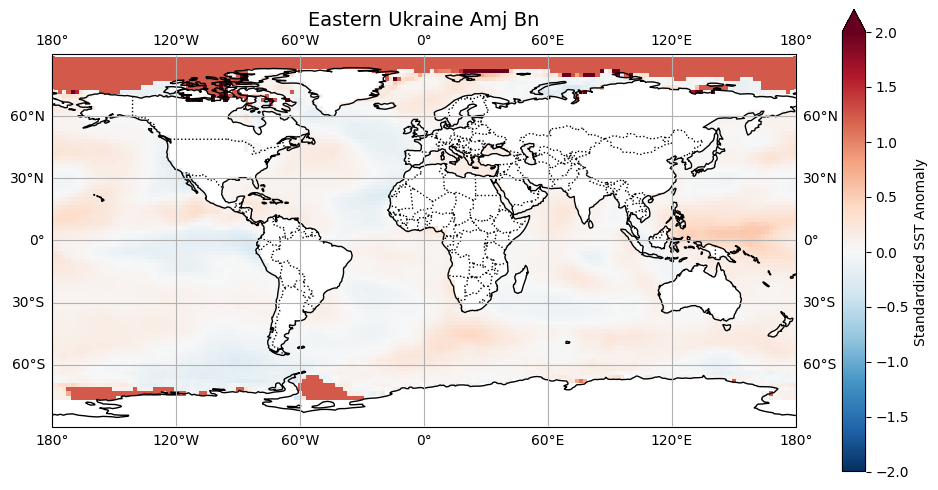

Displaying: eastern_ukraine_AMJ_AN


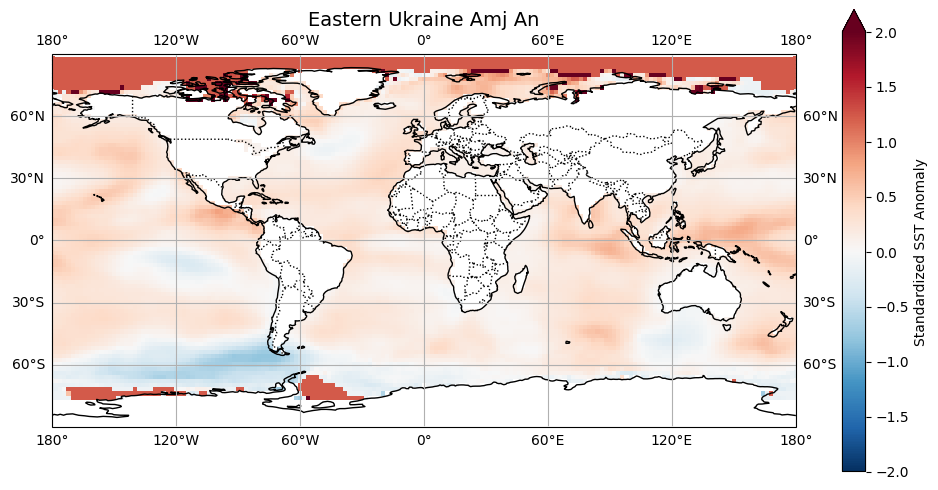

Displaying: eastern_ukraine_JA_BN


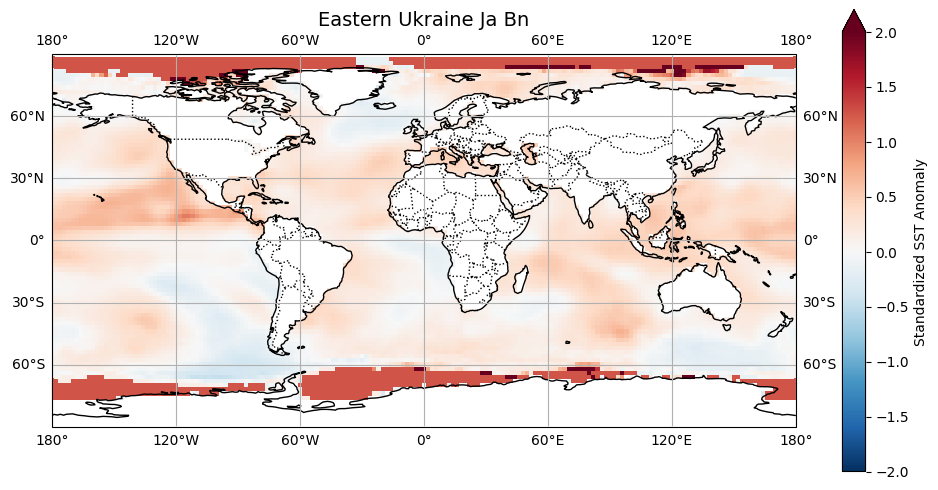

Displaying: eastern_ukraine_JA_AN


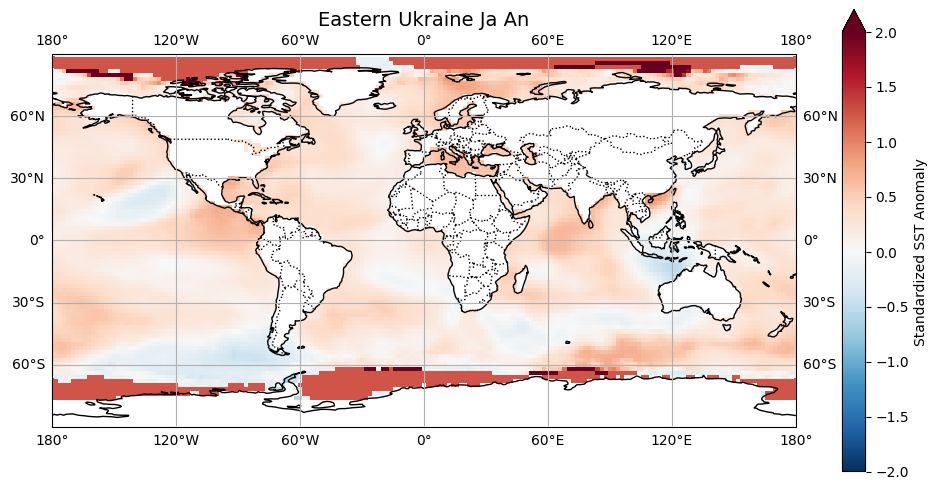

Displaying: southern_africa_DJF_BN


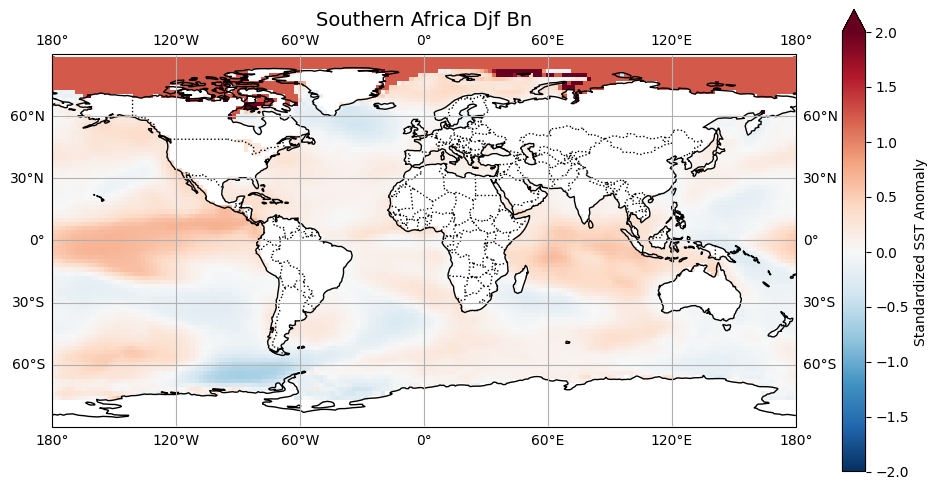

Displaying: southern_africa_DJF_AN


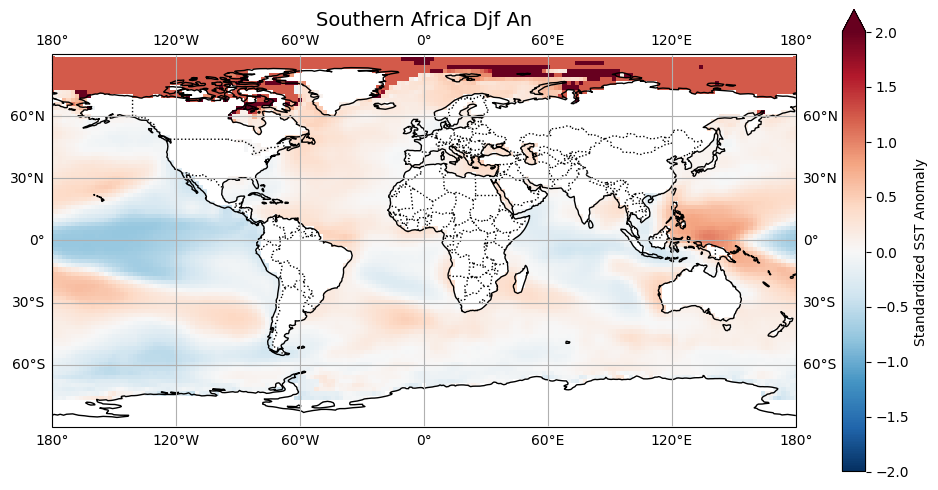

Displaying: southern_africa_FMA_BN


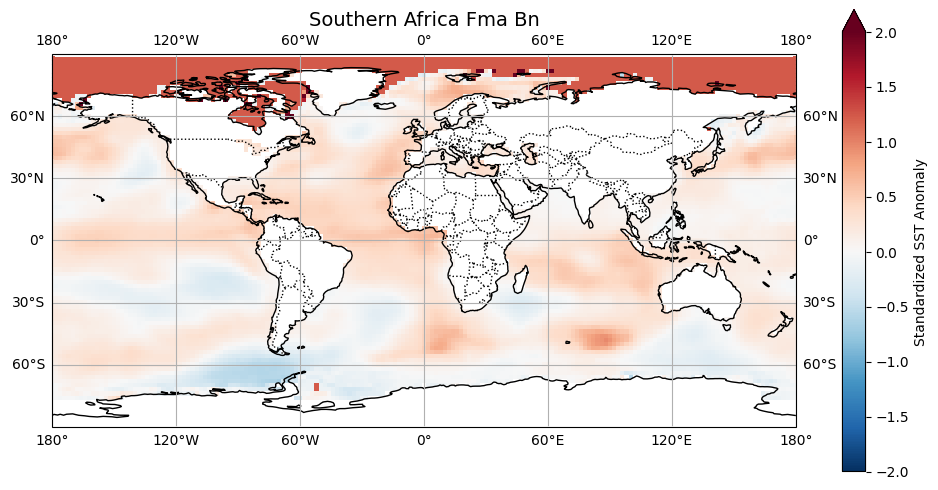

Displaying: southern_africa_FMA_AN


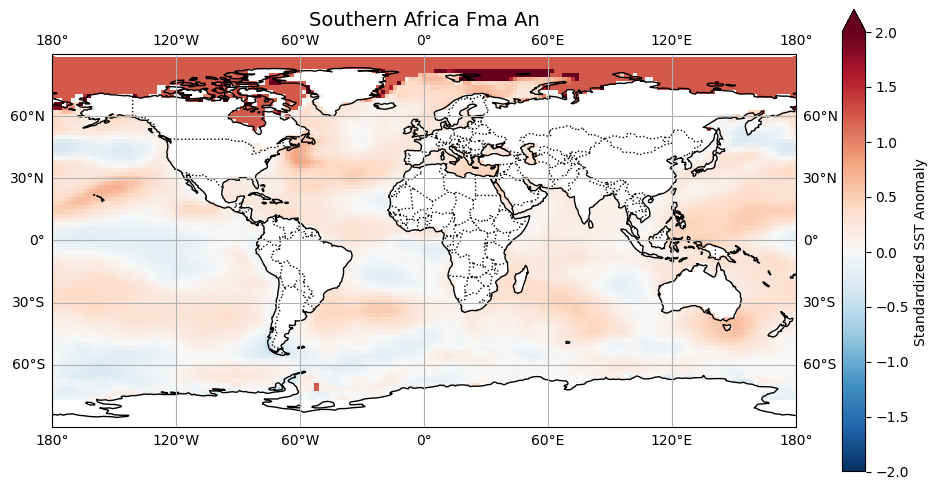

Displaying: west_africa_JAS_BN


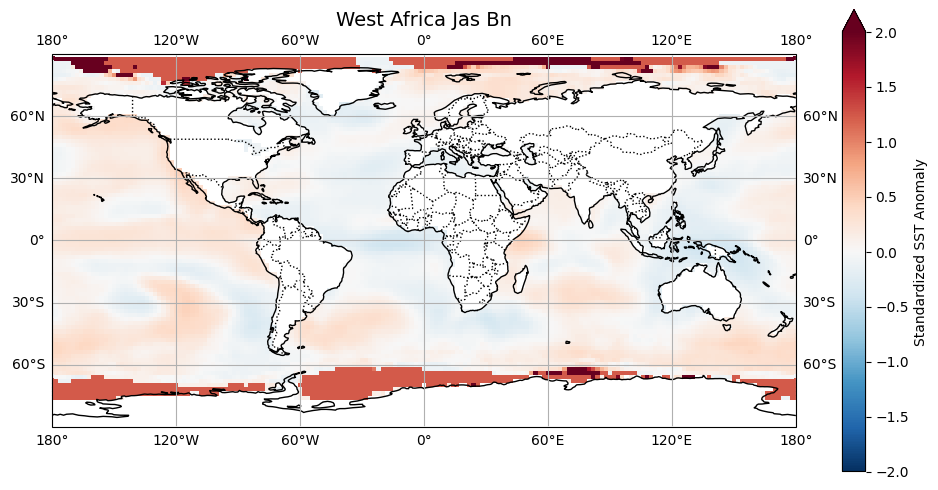

Displaying: west_africa_JAS_AN


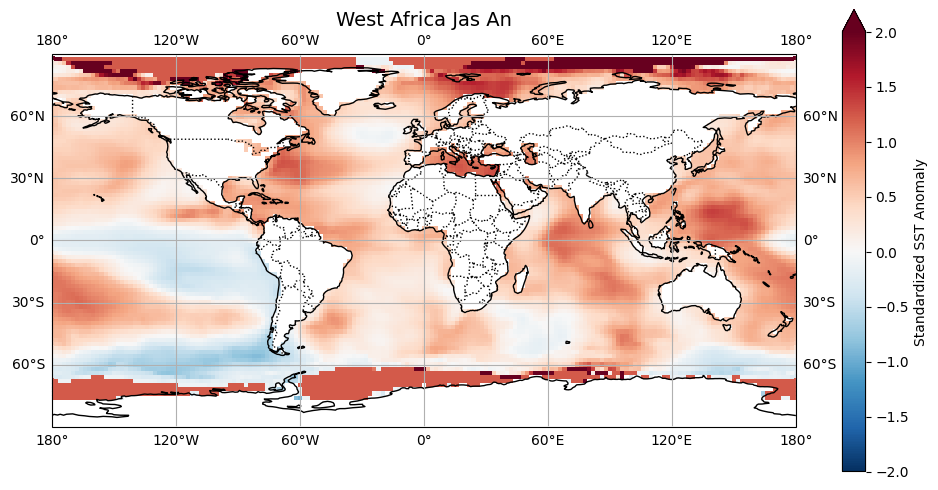

Displaying: sri_lanka_OND_BN


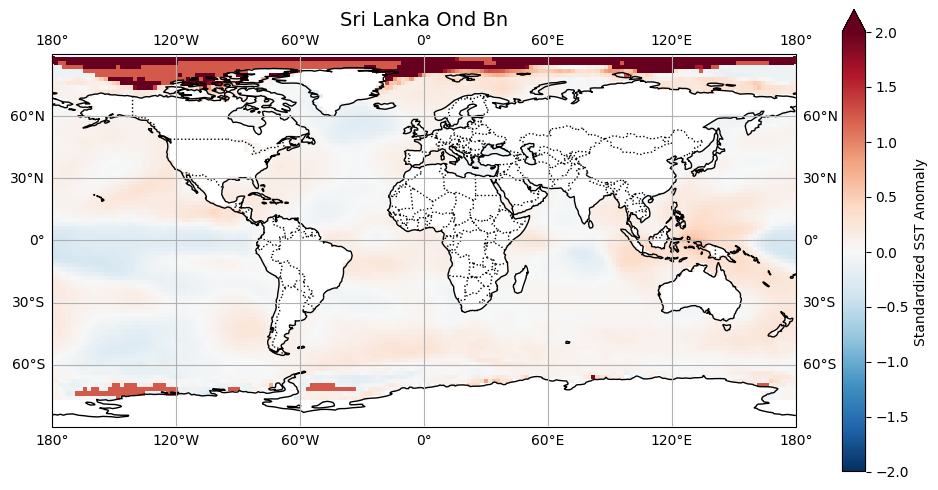

Displaying: sri_lanka_OND_AN


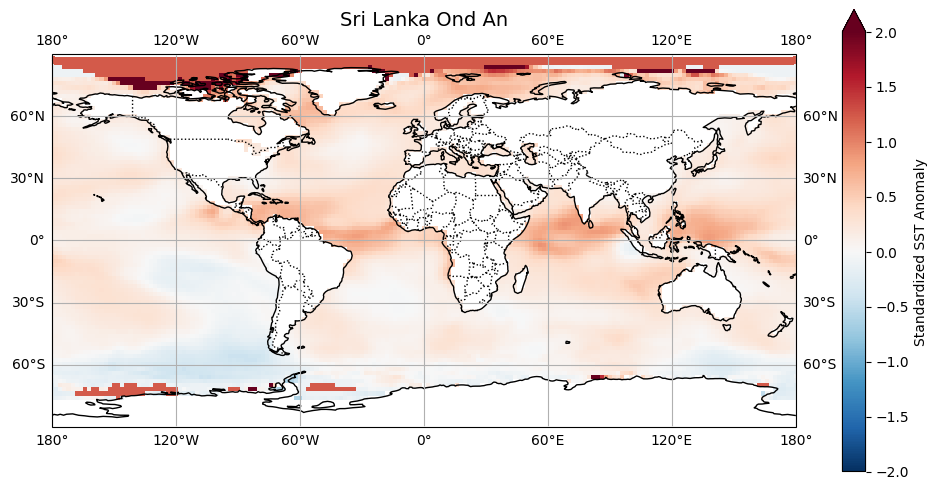

Displaying: lake_victoria_DJF_BN


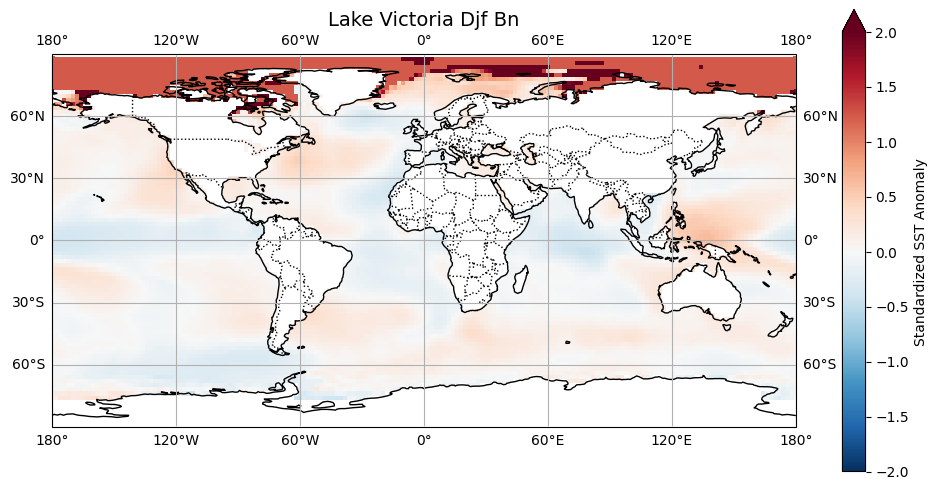

Displaying: lake_victoria_DJF_AN


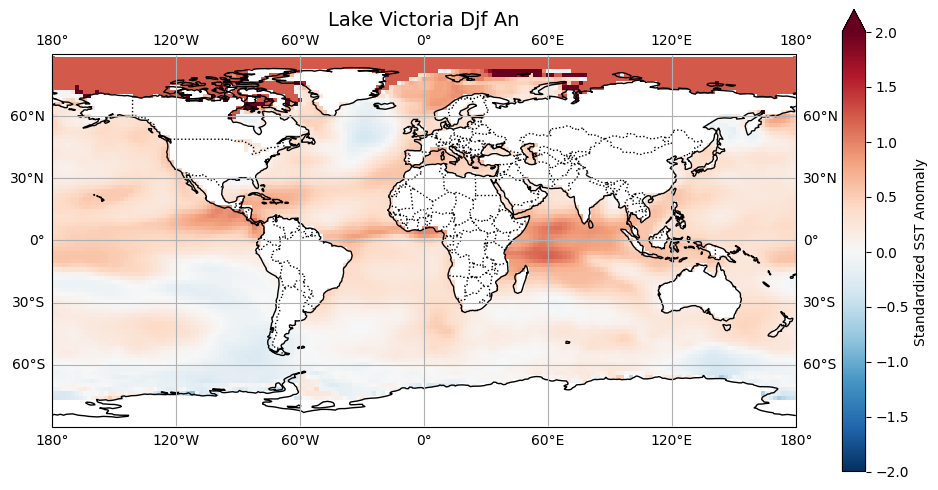

Displaying: lake_victoria_MAM_BN


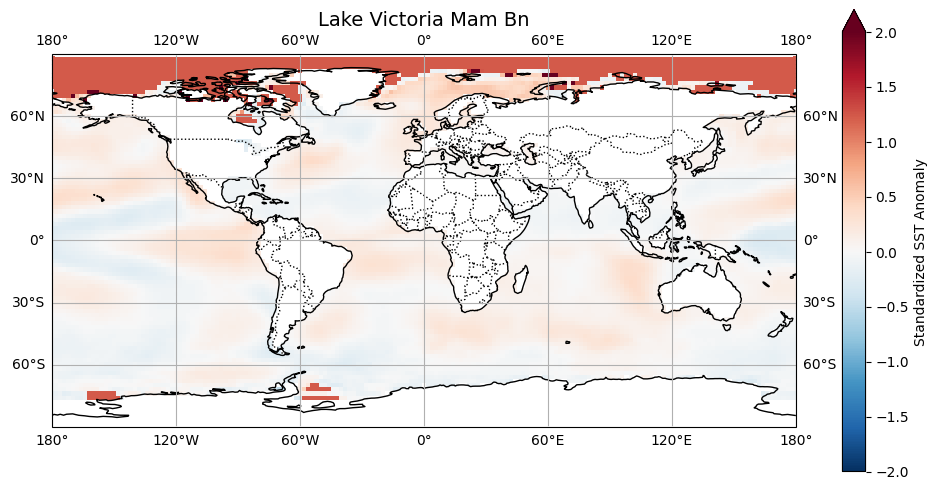

Displaying: lake_victoria_MAM_AN


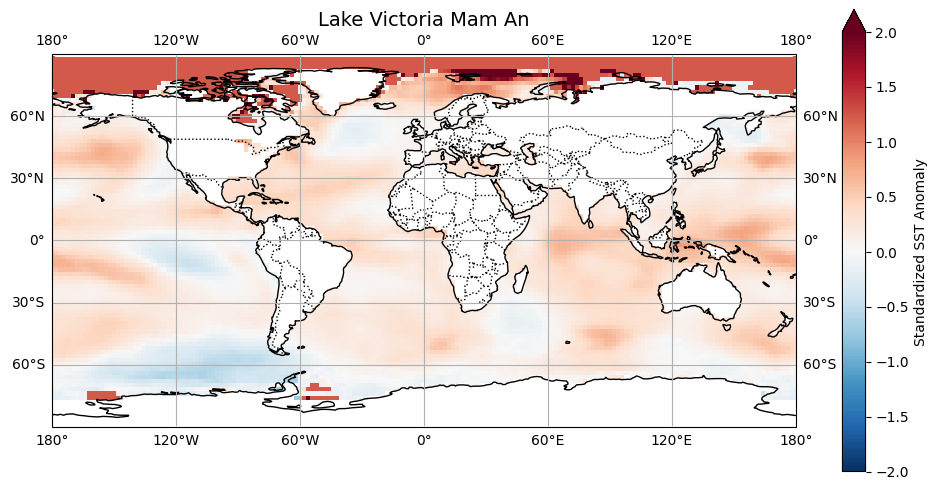

Displaying: lake_victoria_SON_BN


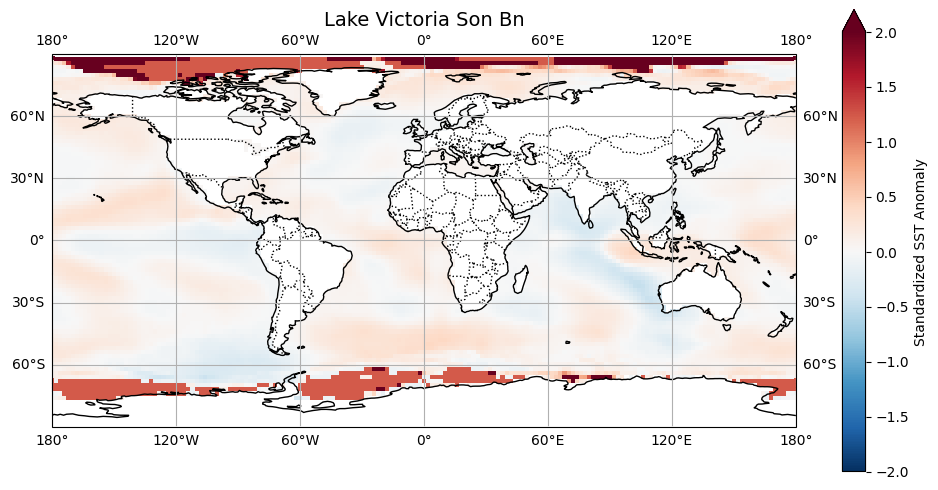

Displaying: lake_victoria_SON_AN


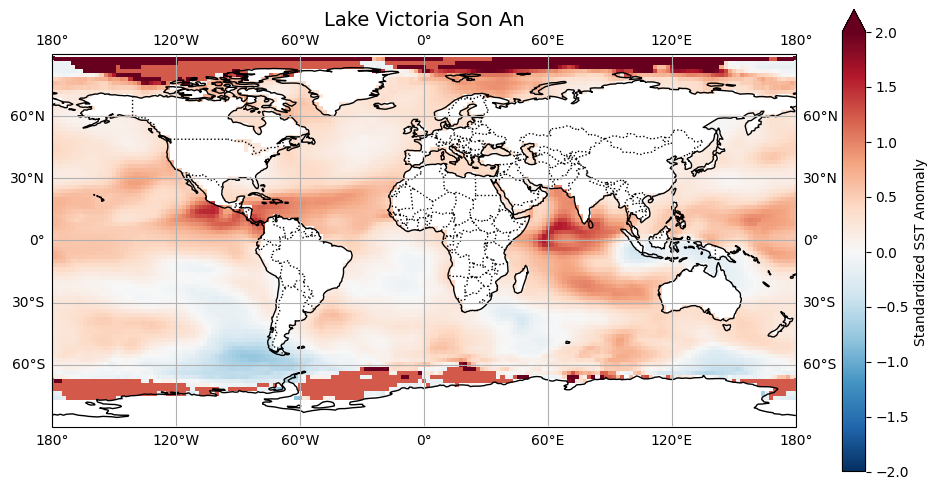

In [22]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Function to plot global SST anomaly (no saving)
def plot_sst_anomaly(anomaly, title):
    plt.figure(figsize=(12, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    anomaly.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        cbar_kwargs={"label": "Standardized SST Anomaly"},
        vmin=-2,
        vmax=2,
    )

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_title(title, fontsize=14)
    ax.set_global()
    ax.gridlines(draw_labels=True)

    plt.show()

for key, anomaly in global_sst_anomalies.items():
    print(f"Displaying: {key}")
    title = key.replace("_", " ").title()
    plot_sst_anomaly(anomaly, title=title)
